# Yellow Taxi Full Data EDA

This notebook re-checks the sample EDA findings that were too unstable or too sample-dependent to trust on the 20K-row sample, using the **full** cleaned Yellow Taxi data.

The full cleaned dataset is too large to commit to this GitHub repo, so it is **not** included here. It will be shared via an external download link (a MEGA link, to be added). The notebook reads the data from a local path, set as `PROCESSED_YELLOW_DIR` in the setup cell below (currently `/Users/ping/Desktop/data/processed/yellow`).

**To run this notebook:** download the full data from the shared link, then change `PROCESSED_YELLOW_DIR` to your own local path.

## Notebook Map

This notebook has two blocks.

**Part I: Time Series and Temporal Structure** uses full card/cash data to inspect monthly cost trends and a YoY cost event study, trip volume and the Flex-adoption confound, daily lag structure, rolling/STL views, pickup-hour CBD exposure, and day-of-week patterns. rolling/STL views.

**Part II: Full-Data Validation Checks** uses full data to re-check sample EDA findings that are not primarily time-series questions: charged vs not-charged composition, burden distribution, and geography/OD rankings.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

PROCESSED_YELLOW_DIR = Path("/Users/ping/Desktop/data/processed/yellow")
ZONE_LOOKUP_PATH = Path("/Users/ping/Documents/GitHub/summer26-congestion-pricing/data/taxi_zone_lookup.csv")

analysis_cols = [
    "year", "month", "pickup_hour", "day_of_week",
    "PULocationID", "DOLocationID",
    "trip_distance_miles", "trip_duration_seconds",
    "cbd_congestion_fee", "charged_cbd_flag",
    "airport_fee", "airport_trip_flag",
    "passenger_cost_pretip", "relative_cbd_burden",
    "payment_type", "yellow_card_or_cash_flag", "irregular_payment_flag",
    "flex_fare_flag", "zero_distance_flag", "very_long_distance_flag",
]

files = sorted(PROCESSED_YELLOW_DIR.glob("*/*.parquet"))
if not files:
    raise FileNotFoundError(f"No processed Yellow Taxi parquet files found under {PROCESSED_YELLOW_DIR}")

parts = [pd.read_parquet(path, columns=analysis_cols) for path in files]
yellow = pd.concat(parts, ignore_index=True)
yellow["trip_duration_minutes"] = yellow["trip_duration_seconds"] / 60

main = yellow[yellow["yellow_card_or_cash_flag"]].copy()
main_2025 = main[main["year"] == 2025].copy()
charged_main_2025 = main_2025[main_2025["charged_cbd_flag"]].copy()

inventory = (
    yellow.groupby(["year", "month"])
    .size()
    .reset_index(name="processed_rows")
)
inventory

,year,month,processed_rows
0,2024,2,2970277
1,2024,3,3536782
2,2024,4,3469080
3,2024,5,3673319
4,2024,6,3488938
5,2025,2,3516753
6,2025,3,4053697
7,2025,4,3862613
8,2025,5,4414520
9,2025,6,4179498


# Part I. Time Series and Temporal Structure

This block studies temporal behavior directly: month-level trends, daily May diagnostics, lag structure, hourly exposure, and payment-regime time patterns.

## 1. Monthly Time Series: Cost, Distance, and Duration

This section starts the time-series block with full card/cash trips only. It checks whether sample-level monthly patterns survive on full data, especially the 2025 cost increase and the April 2025 distance dip.

In [2]:
monthly = (
    main.groupby(["year", "month"])
    .agg(
        rows=("year", "size"),
        median_cost=("passenger_cost_pretip", "median"),
        p25_cost=("passenger_cost_pretip", lambda s: s.quantile(0.25)),
        p75_cost=("passenger_cost_pretip", lambda s: s.quantile(0.75)),
        median_distance=("trip_distance_miles", "median"),
        median_duration_min=("trip_duration_minutes", "median"),
        zero_distance_share=("zero_distance_flag", "mean"),
        airport_share=("airport_trip_flag", "mean"),
    )
    .reset_index()
)
monthly

,year,month,rows,median_cost,p25_cost,p75_cost,median_distance,median_duration_min,zero_distance_share,airport_share
0,2024,2,2745687,17.8000,13.6000,24.9000,1.6900,11.9000,0.0098,0.0723
1,2024,3,3063279,17.9000,13.7000,25.9000,1.7000,12.2000,0.0097,0.0802
2,2024,4,3014501,18.2000,14.0000,26.6000,1.7100,12.5167,0.0094,0.0825
3,2024,5,3217385,18.6000,14.0000,27.3000,1.7300,13.0667,0.0096,0.0846
4,2024,6,3027491,18.2000,14.0000,26.9000,1.7300,12.7000,0.0101,0.0843
5,2025,2,2657469,17.8500,14.0000,24.8500,1.6100,11.5667,0.0097,0.0705
6,2025,3,3071031,18.2500,14.0500,25.9500,1.7000,11.9333,0.0094,0.0778
7,2025,4,3047716,18.6500,14.3500,26.3500,1.6900,12.3667,0.0096,0.0773
8,2025,5,3178439,19.2500,14.7000,28.0000,1.7100,13.0333,0.0093,0.0880
9,2025,6,2896629,18.9500,14.4500,27.6500,1.7300,12.5833,0.0091,0.0910


In [3]:
yoy_rows = []
monthly_pivot = monthly.pivot(index="month", columns="year", values=["rows", "median_cost", "median_distance", "median_duration_min"])
for month in sorted(monthly["month"].unique()):
    yoy_rows.append({
        "month": month,
        "median_cost_diff_2025_minus_2024": monthly_pivot[("median_cost", 2025)].loc[month] - monthly_pivot[("median_cost", 2024)].loc[month],
        "median_distance_diff_2025_minus_2024": monthly_pivot[("median_distance", 2025)].loc[month] - monthly_pivot[("median_distance", 2024)].loc[month],
        "median_duration_min_diff_2025_minus_2024": monthly_pivot[("median_duration_min", 2025)].loc[month] - monthly_pivot[("median_duration_min", 2024)].loc[month],
        "row_count_pct_change_2025_vs_2024": 100 * (monthly_pivot[("rows", 2025)].loc[month] / monthly_pivot[("rows", 2024)].loc[month] - 1),
    })
yoy_monthly = pd.DataFrame(yoy_rows)
yoy_monthly

,month,median_cost_diff_2025_minus_2024,median_distance_diff_2025_minus_2024,median_duration_min_diff_2025_minus_2024,row_count_pct_change_2025_vs_2024
0,2,0.0500,-0.0800,-0.3333,-3.2130
1,3,0.3500,0.0000,-0.2667,0.2531
2,4,0.4500,-0.0200,-0.1500,1.1018
3,5,0.6500,-0.0200,-0.0333,-1.2105
4,6,0.7500,0.0000,-0.1167,-4.3225


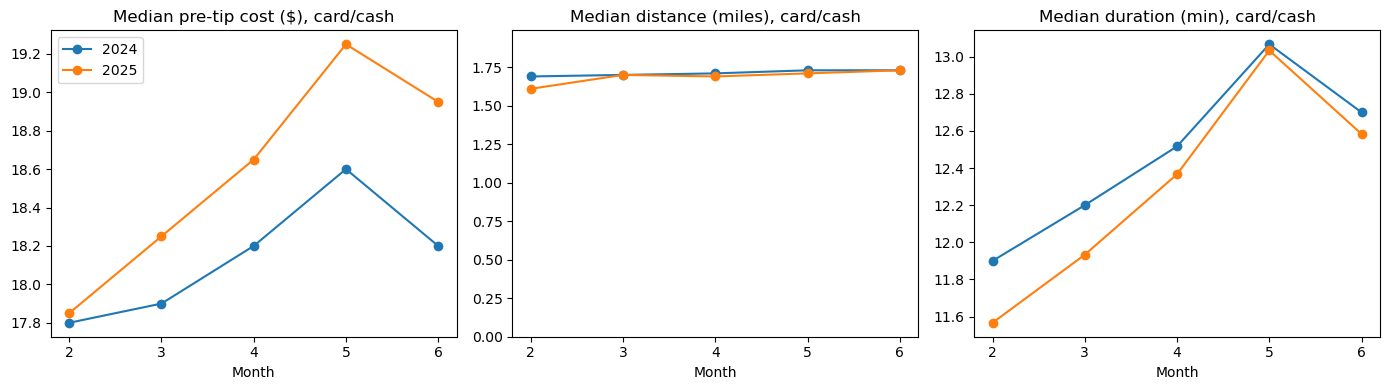

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
plot_specs = [
    ("median_cost", "Median pre-tip cost ($), card/cash"),
    ("median_distance", "Median distance (miles), card/cash"),
    ("median_duration_min", "Median duration (min), card/cash"),
]
for ax, (col, title) in zip(axes, plot_specs):
    for year in [2024, 2025]:
        g = monthly[monthly["year"] == year]
        ax.plot(g["month"], g[col], marker="o", label=str(year))
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_xticks([2, 3, 4, 5, 6])
    if col == "median_distance":
        ax.set_ylim(0, monthly[col].max() * 1.15)
axes[0].legend()
plt.tight_layout()
plt.show()

**Finding:** within card/cash trips, the 2025 cost increase is real but modest: same-month median cost is `$0.05-$0.75` higher than 2024. The April 2025 distance dip from the sample does not survive strongly; full-data card/cash median distance is close to adjacent months and only `0.02` miles below April 2024. The distance axis is shown from zero because the month-to-month distance differences are small.

May is the cost and duration peak in both years, which argues against a simple inflation-only explanation. In the full data, May also has high upper-quartile cost/distance/duration and elevated airport-trip share, suggesting a seasonal mix of longer trips and slower traffic.

### Year-over-year cost trajectory (event study)

The same monthly data viewed as the YoY **percentage** change in median cost (card/cash), with a zero line. January is excluded, so the x-axis starts in February — this reads the shape across the post window (stable vs. growing), not the Jan 5 jump. (Trip volume is handled in section 2.)

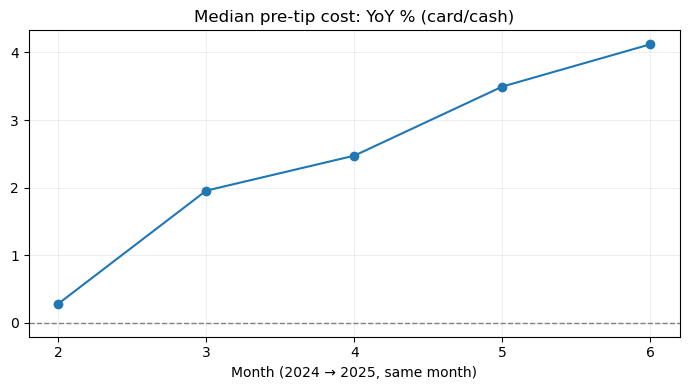

In [5]:
# Event-study view: year-over-year % change in median cost by month (card/cash).
# Uses monthly_pivot built in section 1.
fig, ax = plt.subplots(figsize=(7, 4))
pct = 100 * (monthly_pivot[("median_cost", 2025)] / monthly_pivot[("median_cost", 2024)] - 1)
ax.plot(pct.index, pct.values, marker="o")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Median pre-tip cost: YoY % (card/cash)")
ax.set_xlabel("Month (2024 \u2192 2025, same month)")
ax.set_xticks([2, 3, 4, 5, 6])
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Finding (event study):** 2025 same-month median pre-tip cost is above 2024 in every month, and the gap widens steadily from ~+0.3% in February to ~+4.1% in June. This is a general fare-level increase accumulating through 2025, not the CBD fee itself (the flat $0.75 is small and roughly constant).

## 2. Trip Volume: Combined Yellow Demand & the Flex Confound

We use the full yellow population (card/cash and Flex Fare) to count the volume change.

- **Left:** YoY % change in total yellow trips — volume rose ~11–20% in every post-policy month.
- **Right:** Flex Fare's share of trips roughly doubled–tripled (≈6–12% in 2024 → ≈19–29% in 2025).



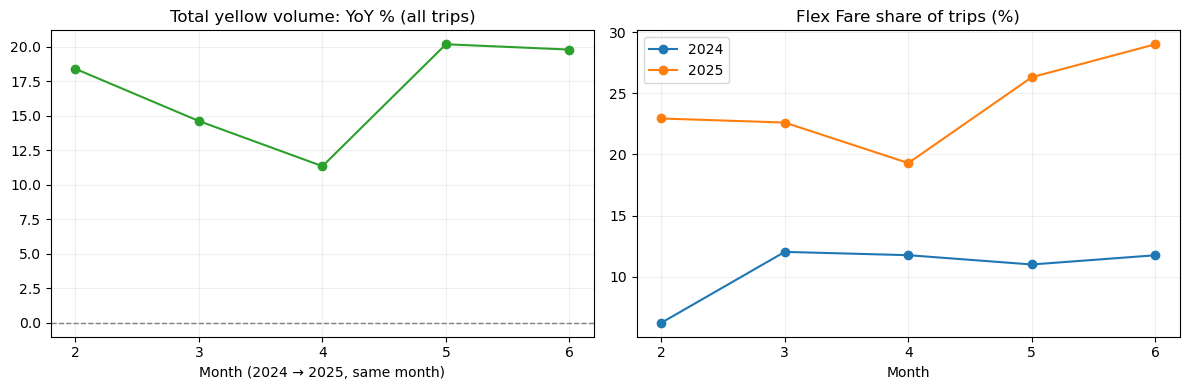

In [6]:
# Volume must include the full yellow population (card/cash + Flex), so it uses the full `yellow` frame.
vol = yellow.groupby(["year", "month"]).size().rename("trips").reset_index()
vol_pivot = vol.pivot(index="month", columns="year", values="trips")
vol_yoy = 100 * (vol_pivot[2025] / vol_pivot[2024] - 1)

flex_share = (
    yellow.groupby(["year", "month"])["flex_fare_flag"].mean().mul(100).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vol_yoy.index, vol_yoy.values, marker="o", color="tab:green")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Total yellow volume: YoY % (all trips)")
axes[0].set_xlabel("Month (2024 \u2192 2025, same month)")
axes[0].set_xticks([2, 3, 4, 5, 6])
axes[0].grid(alpha=0.2)

for year in [2024, 2025]:
    g = flex_share[flex_share["year"] == year]
    axes[1].plot(g["month"], g["flex_fare_flag"], marker="o", label=str(year))
axes[1].set_title("Flex Fare share of trips (%)")
axes[1].set_xlabel("Month")
axes[1].set_xticks([2, 3, 4, 5, 6])
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Findings:** The volume increase is driven by Flex adoption, a booking-channel trend, **not** the congestion fee — so raw yellow volume is not a clean policy signal. Whether Flex is pulling riders from Uber/Lyft (cross-service substitution) cannot be seen here; it needs HVFHV data to verify. 

## 3. Exploratory Lag Structure

This section we study the lag features to inspect autocorrelation and short-run persistence, on the **on-scope** daily series — trip volume and median pre-tip cost (card/cash, both valid in 2024 and 2025). 
Duration/distance series dropped as off-scope; CBD-charged share is examined by hour in section 7, since it is 2025-only.

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load date-level card/cash fields for the daily series (on-scope: volume + cost).
daily_cols = [
    "pickup_datetime", "year", "month",
    "passenger_cost_pretip", "yellow_card_or_cash_flag",
]
daily_parts = [pd.read_parquet(path, columns=daily_cols) for path in files]
daily = pd.concat(daily_parts, ignore_index=True)
daily = daily[daily["yellow_card_or_cash_flag"]].copy()
daily["pickup_date"] = pd.to_datetime(daily["pickup_datetime"].dt.date)

# Daily card/cash aggregate over the full Feb-Jun window.
daily_ts = (
    daily.groupby(["year", "pickup_date"])
    .agg(
        trip_count=("year", "size"),
        median_cost=("passenger_cost_pretip", "median"),
    )
    .reset_index()
    .sort_values(["year", "pickup_date"])
)

for col in ["trip_count", "median_cost"]:
    daily_ts[f"{col}_lag1"] = daily_ts.groupby("year")[col].shift(1)
    daily_ts[f"{col}_lag7"] = daily_ts.groupby("year")[col].shift(7)

daily_ts.head(10)

,year,pickup_date,trip_count,median_cost,trip_count_lag1,trip_count_lag7,median_cost_lag1,median_cost_lag7
0,2024,2024-02-01,102958,18.2000,NaN,NaN,NaN,NaN
1,2024,2024-02-02,99016,17.5000,102958.0000,NaN,18.2000,NaN
2,2024,2024-02-03,101848,16.8000,99016.0000,NaN,17.5000,NaN
3,2024,2024-02-04,81705,17.0000,101848.0000,NaN,16.8000,NaN
4,2024,2024-02-05,83771,17.5000,81705.0000,NaN,17.0000,NaN
5,2024,2024-02-06,96224,17.9000,83771.0000,NaN,17.5000,NaN
6,2024,2024-02-07,96919,18.5000,96224.0000,NaN,17.9000,NaN
7,2024,2024-02-08,106379,18.5000,96919.0000,102958.0000,18.5000,18.2000
8,2024,2024-02-09,102080,18.2000,106379.0000,99016.0000,18.5000,17.5000
9,2024,2024-02-10,103561,17.1000,102080.0000,101848.0000,18.2000,16.8000


In [8]:
# Interactive line plot for visual inspection.
try:
    import plotly.express as px
    fig = px.line(
        daily_ts,
        x="pickup_date",
        y="median_cost",
        color="year",
        title="Daily median pre-tip cost, card/cash trips",
        labels={"median_cost": "Median pre-tip cost ($)", "pickup_date": "Pickup date"},
    )
    fig.show()
except Exception as exc:
    print(f"Plotly display skipped: {exc}")
    fig, ax = plt.subplots(figsize=(12, 4))
    for year, g in daily_ts.groupby("year"):
        ax.plot(g["pickup_date"], g["median_cost"], label=str(year))
    ax.set_title("Daily median pre-tip cost, card/cash trips")
    ax.legend()
    plt.tight_layout()
    plt.show()

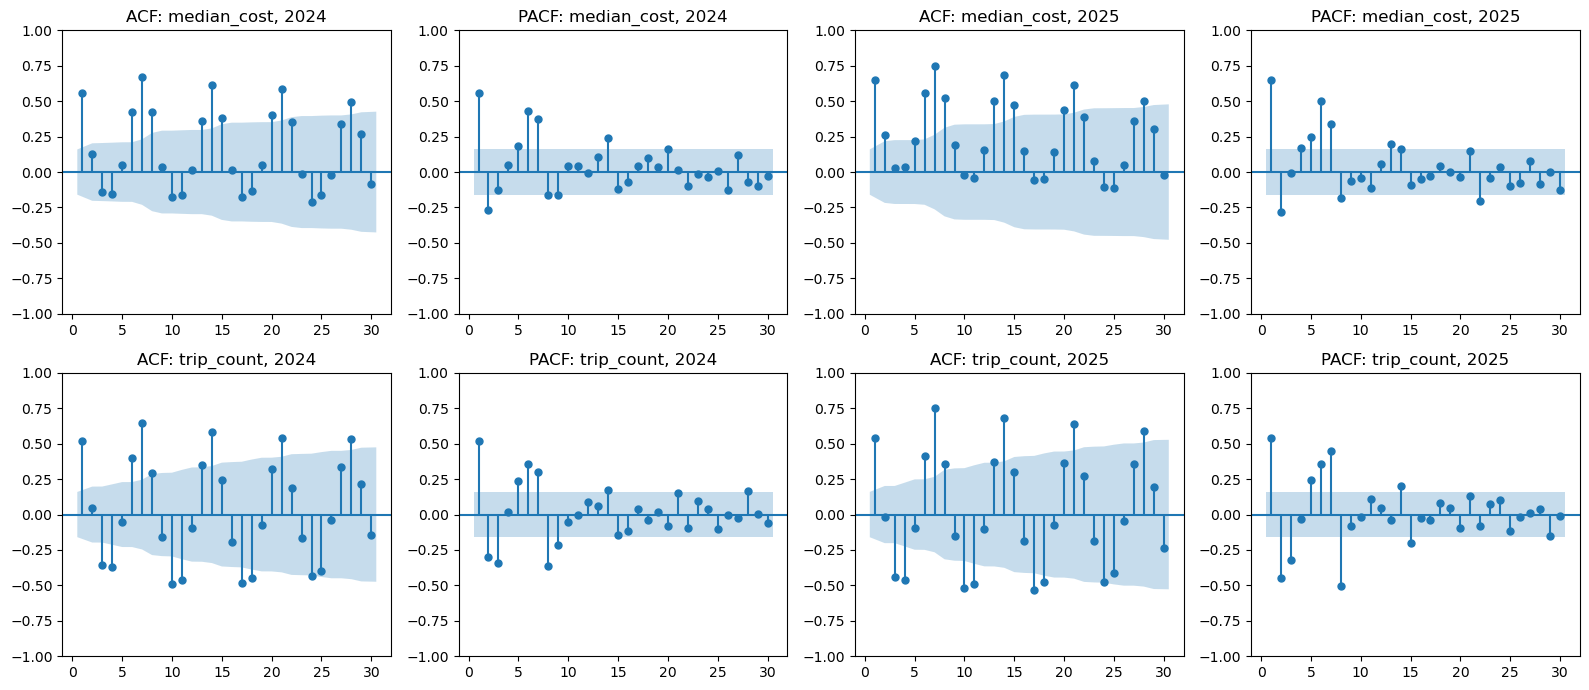

In [9]:
# ACF/PACF are inspected separately by year to avoid treating the 2024->2025 break as one continuous series.
acf_vars = ["median_cost", "trip_count"]
fig, axes = plt.subplots(len(acf_vars), 4, figsize=(16, 7))
for row, var in enumerate(acf_vars):
    for col_idx, year in enumerate([2024, 2025]):
        series = daily_ts.loc[daily_ts["year"] == year, var].dropna()
        plot_acf(series, lags=30, ax=axes[row, col_idx * 2], zero=False)
        axes[row, col_idx * 2].set_title(f"ACF: {var}, {year}")
        plot_pacf(series, lags=30, ax=axes[row, col_idx * 2 + 1], zero=False, method="ywm")
        axes[row, col_idx * 2 + 1].set_title(f"PACF: {var}, {year}")
plt.tight_layout()
plt.show()

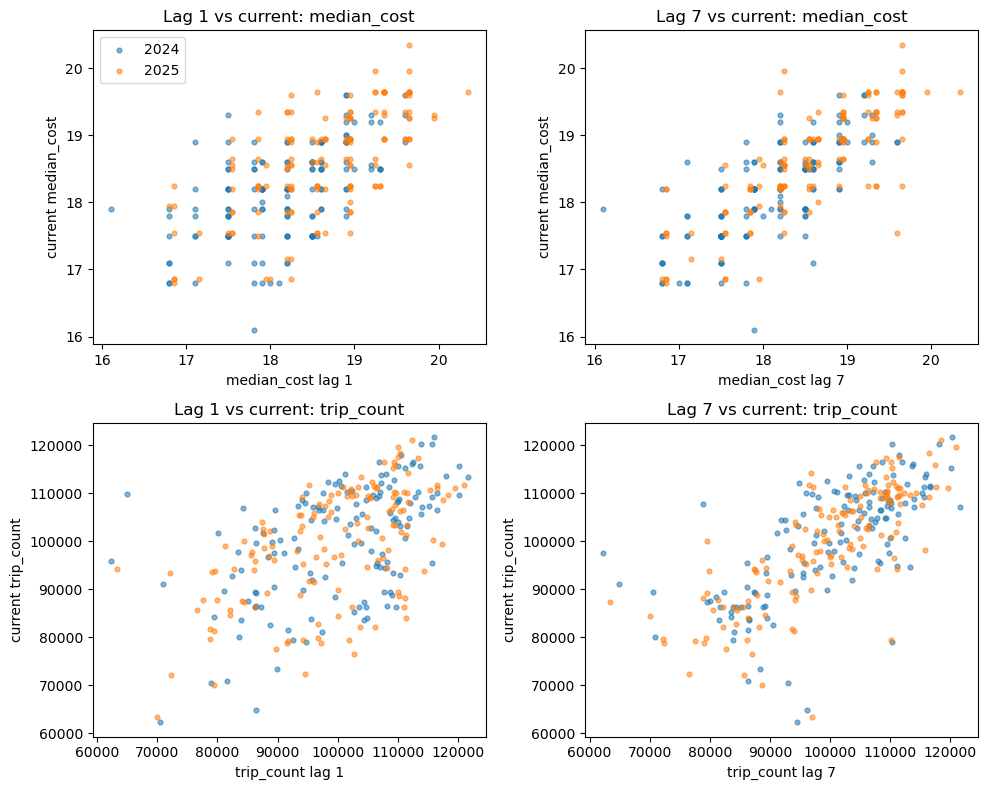

In [10]:
# Lag-target scatterplots: useful for diagnosing persistence without fitting a predictive model.
scatter_vars = ["median_cost", "trip_count"]
fig, axes = plt.subplots(len(scatter_vars), 2, figsize=(10, 8))
for row, var in enumerate(scatter_vars):
    plot_df = daily_ts.dropna(subset=[var, f"{var}_lag1", f"{var}_lag7"])
    for ax, lag in zip(axes[row], [1, 7]):
        for year, g in plot_df.groupby("year"):
            ax.scatter(g[f"{var}_lag{lag}"], g[var], s=12, alpha=0.55, label=str(year))
        ax.set_xlabel(f"{var} lag {lag}")
        ax.set_ylabel(f"current {var}")
        ax.set_title(f"Lag {lag} vs current: {var}")
        if row == 0 and lag == 1:
            ax.legend()
plt.tight_layout()
plt.show()

In [11]:
lag_correlations = []
for year, g in daily_ts.groupby("year"):
    for var in ["median_cost", "trip_count"]:
        lag_correlations.append({
            "year": year,
            "variable": var,
            "lag1_corr": g[[var, f"{var}_lag1"]].corr().iloc[0, 1],
            "lag7_corr": g[[var, f"{var}_lag7"]].corr().iloc[0, 1],
        })
lag_correlation_summary = pd.DataFrame(lag_correlations)
lag_correlation_summary

,year,variable,lag1_corr,lag7_corr
0,2024,median_cost,0.5560,0.7116
1,2024,trip_count,0.5248,0.6714
2,2025,median_cost,0.6622,0.7918
3,2025,trip_count,0.5474,0.7782


**Findings:** For both median cost and trip volume, the lag-7 correlation exceeds the lag-1 correlation in both years (cost: lag-1 ≈ 0.56/0.66 vs lag-7 ≈ 0.71/0.79; volume: lag-1 ≈ 0.52/0.55 vs lag-7 ≈ 0.67/0.78). So these daily series are driven more by **day-of-week (weekly) seasonality** than by pure day-to-day persistence — a given day resembles the same weekday a week earlier more than it resembles yesterday. The pattern is stable across 2024 and 2025. 

This is diagnostic only: it confirms weekly seasonality.

## 4. Rolling-Mean Smoothing of Daily Series

Raw daily values are dominated by the weekly cycle. Each series is shown faint (raw) with a bold 7-day centered moving average overlaid, by year, for trip volume and median pre-tip cost.

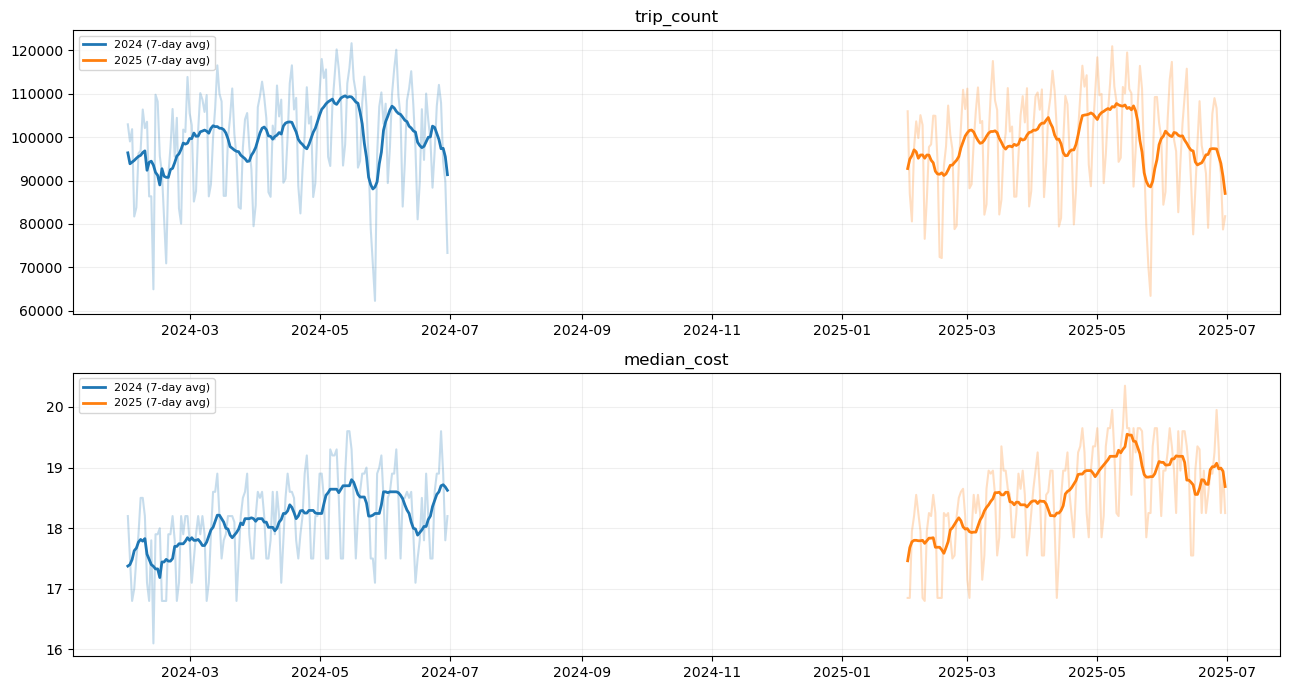

In [12]:
# Faint raw daily series with a bold 7-day centered moving average, by year.
roll_vars = ["trip_count", "median_cost"]
dts = daily_ts.copy()
for col in roll_vars:
    dts[f"{col}_roll7"] = dts.groupby("year")[col].transform(
        lambda s: s.rolling(7, center=True, min_periods=1).mean()
    )

fig, axes = plt.subplots(len(roll_vars), 1, figsize=(13, 7))
for ax, col in zip(axes, roll_vars):
    for year in [2024, 2025]:
        g = dts[dts["year"] == year].sort_values("pickup_date")
        base = ax.plot(g["pickup_date"], g[col], alpha=0.25)[0]
        ax.plot(g["pickup_date"], g[f"{col}_roll7"], linewidth=2,
                color=base.get_color(), label=f"{year} (7-day avg)")
    ax.set_title(col)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding (smoothed trend):** The 7-day average strips out the weekly cycle and shows median cost trending up within each year, with 2025 sitting consistently above 2024; trip volume follows a spring seasonal hump (rising into a May peak, then easing) at a similar level in both years.

## 5. Seasonal Decomposition (STL)

STL splits daily `trip_count` into trend + weekly-seasonal + residual (period = 7), per year. This makes the weekly seasonality explicit and isolates the underlying trend from the day-of-week pattern. Interested readers can change `stl_var` to `median_cost` to decompose cost instead.

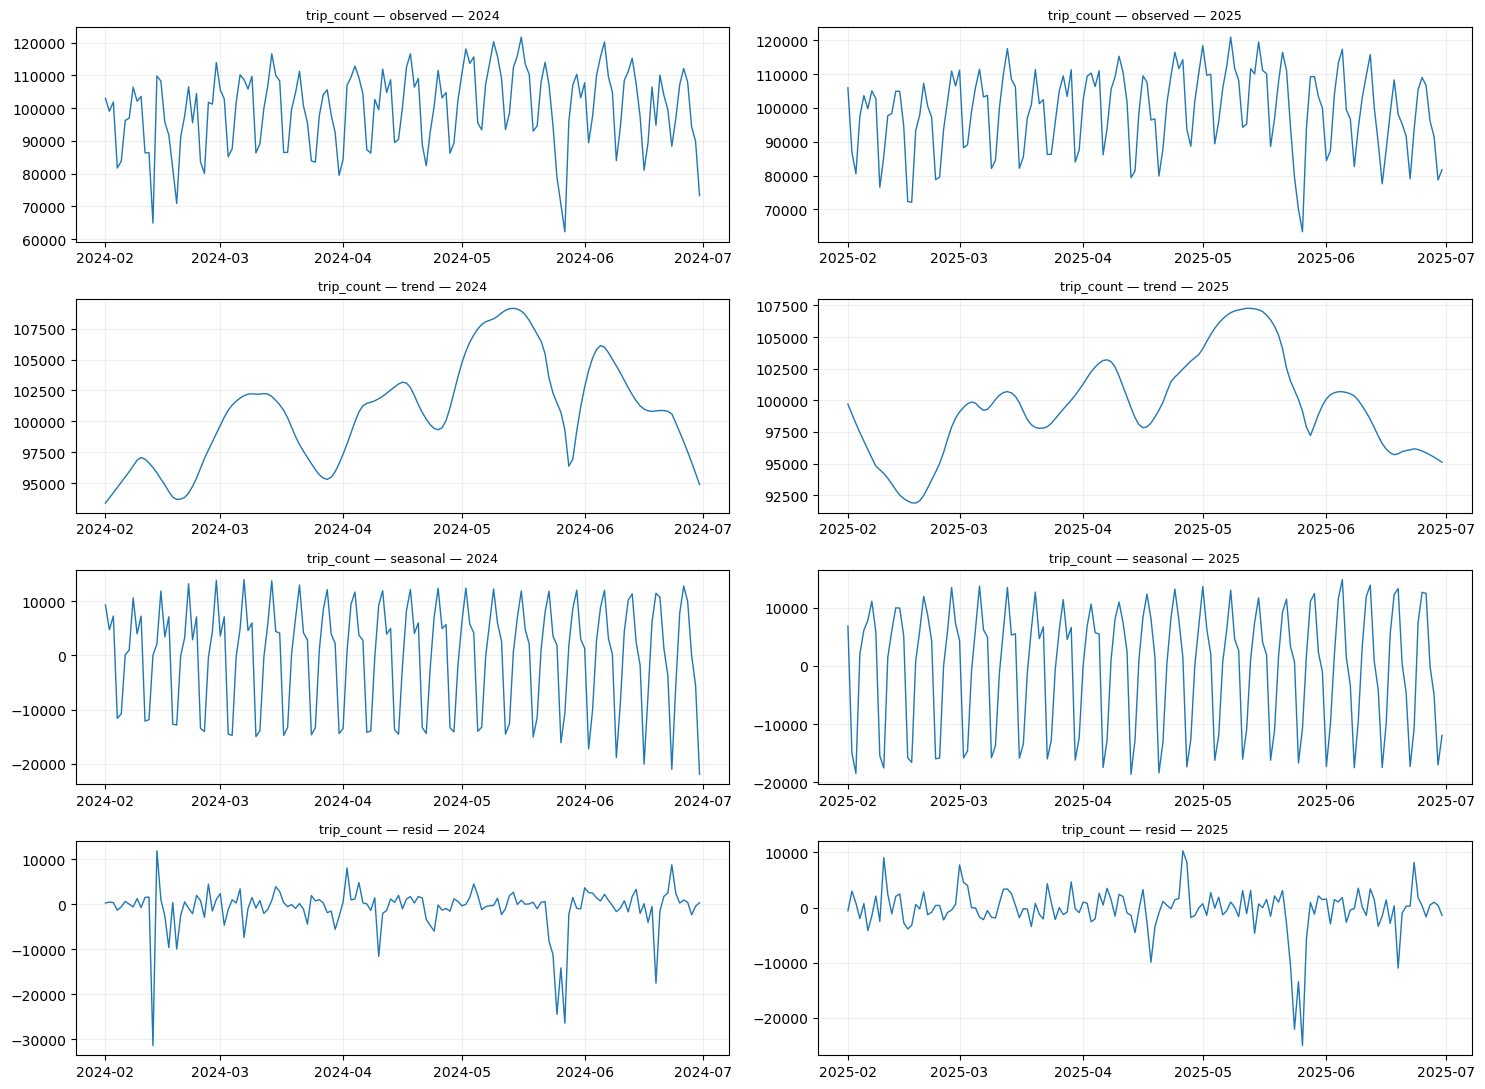

In [13]:
from statsmodels.tsa.seasonal import STL

# Decompose a daily series into trend + weekly seasonal + residual, separately by year.
stl_var = "trip_count"
fig, axes = plt.subplots(4, 2, figsize=(15, 11))
for col_idx, year in enumerate([2024, 2025]):
    g = daily_ts[daily_ts["year"] == year].set_index("pickup_date").sort_index()
    series = g[stl_var].asfreq("D").interpolate()
    res = STL(series, period=7, robust=True).fit()
    components = [
        ("observed", res.observed),
        ("trend", res.trend),
        ("seasonal", res.seasonal),
        ("resid", res.resid),
    ]
    for row, (name, comp) in enumerate(components):
        ax = axes[row, col_idx]
        ax.plot(comp.index, comp.values, linewidth=1)
        ax.set_title(f"{stl_var} \u2014 {name} \u2014 {year}", fontsize=9)
        ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Finding (STL):** Decomposing daily trip volume (period = 7) gives the same picture in both years — a smooth spring trend (rising into a May peak, then easing), a stable weekly seasonal swing of roughly ±15k, and small residuals apart from sharp recurring dips around late May (Memorial Day). 

## 6. Time-of-Day CBD Exposure

This temporal profile checks whether CBD charging varies by pickup hour. The sample showed a counter-intuitive pattern: deep night hours had high charged share, while early morning hours had low charged share. Full data confirms whether this was sample noise.

In [14]:
hourly_2025_all = (
    yellow[yellow["year"] == 2025]
    .groupby("pickup_hour")
    .agg(rows=("year", "size"), charged_cbd_share=("charged_cbd_flag", "mean"))
    .reset_index()
)

hourly_2025_main = (
    main_2025.groupby("pickup_hour")
    .agg(
        rows=("year", "size"),
        charged_cbd_share=("charged_cbd_flag", "mean"),
        median_relative_burden_charged=("relative_cbd_burden", lambda s: s[main_2025.loc[s.index, "charged_cbd_flag"]].median()),
    )
    .reset_index()
)

hourly_extremes = pd.concat([
    hourly_2025_main.assign(charged_cbd_share_pct=lambda d: 100 * d["charged_cbd_share"]).nsmallest(5, "charged_cbd_share_pct"),
    hourly_2025_main.assign(charged_cbd_share_pct=lambda d: 100 * d["charged_cbd_share"]).nlargest(5, "charged_cbd_share_pct"),
])
hourly_extremes

,pickup_hour,rows,charged_cbd_share,median_relative_burden_charged,charged_cbd_share_pct
5,5,81722,0.6561,0.0420,65.6127
6,6,185614,0.6785,0.0464,67.8543
7,7,380523,0.6819,0.0445,68.1859
8,8,535002,0.7046,0.0427,70.4624
10,10,695113,0.7059,0.0396,70.5941
2,2,161461,0.9042,0.0420,90.4150
3,3,105314,0.9006,0.0420,90.0574
1,1,251258,0.8715,0.0420,87.1530
0,0,387692,0.8384,0.0404,83.8377
23,23,561372,0.8192,0.0390,81.9227


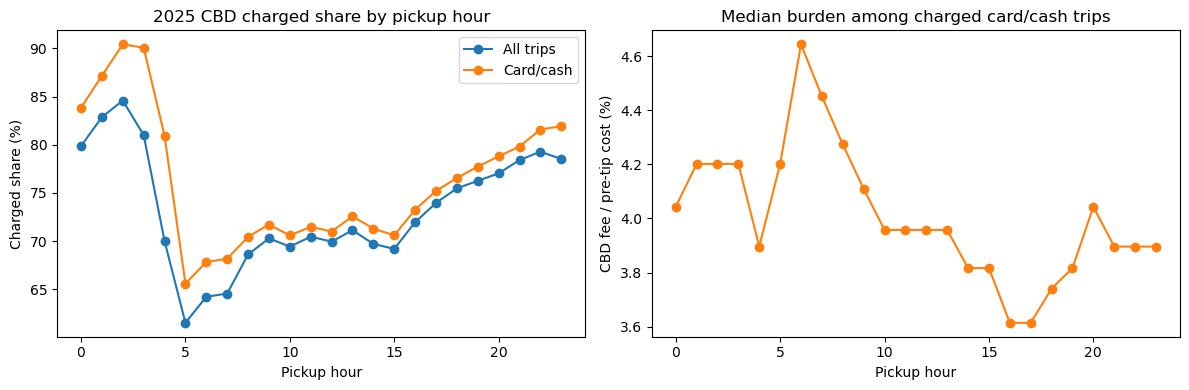

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hourly_2025_all["pickup_hour"], 100 * hourly_2025_all["charged_cbd_share"], marker="o", label="All trips")
axes[0].plot(hourly_2025_main["pickup_hour"], 100 * hourly_2025_main["charged_cbd_share"], marker="o", label="Card/cash")
axes[0].set_title("2025 CBD charged share by pickup hour")
axes[0].set_xlabel("Pickup hour")
axes[0].set_ylabel("Charged share (%)")
axes[0].legend()

axes[1].plot(hourly_2025_main["pickup_hour"], 100 * hourly_2025_main["median_relative_burden_charged"], marker="o", color="tab:orange")
axes[1].set_title("Median burden among charged card/cash trips")
axes[1].set_xlabel("Pickup hour")
axes[1].set_ylabel("CBD fee / pre-tip cost (%)")
plt.tight_layout()
plt.show()

**Finding:** the exposure pattern is not sample noise. Among 2025 card/cash trips, charged share is lowest around `5-8am` and highest around `1-3am`; the range is roughly `66%-90%`. Median burden is much flatter, mostly around `3.6%-4.6%`.

**Interpretation (hourly exposure):** Charged share is a composition measure — the share of each hour's trips that touch the CRZ. The deep-night peak (~1–3am, ~90% card/cash) is consistent with the few trips still running being concentrated in the Manhattan core (nightlife heading home), while the ~5am trough (~65%) is consistent with early outer-borough trips diluting the CRZ share. So the uneven profile reflects *where* activity sits by hour, not noise.

Median burden ≈ fee / fare, so it moves inversely with typical trip cost: the small morning bump (~6am, ~4.6%) is consistent with shorter/cheaper charged trips, and the afternoon low (~3.6%) with longer/pricier ones. The overall range is narrow (~3.6–4.6%), so only the broad shape should be read, not the point-to-point wiggles.

## 7. Payment-Regime Time Patterns

Flex Fare is examined as a temporal/payment-regime diagnostic, not as part of the main burden population. The goal is to compare Flex Fare against card/cash by hour and day of week while keeping the financial analysis stratified.

In [16]:
regime_2025 = yellow[(yellow["year"] == 2025) & (yellow["payment_type"].isin([0, 1, 2]))].copy()
regime_2025["regime"] = np.where(regime_2025["flex_fare_flag"], "Flex Fare", "Card/Cash")

regime_hour = (
    regime_2025.groupby(["pickup_hour", "regime"])
    .agg(
        rows=("year", "size"),
        charged_cbd_share=("charged_cbd_flag", "mean"),
        median_cost=("passenger_cost_pretip", "median"),
    )
    .reset_index()
)

regime_dow = (
    regime_2025.groupby(["day_of_week", "regime"])
    .agg(
        rows=("year", "size"),
        charged_cbd_share=("charged_cbd_flag", "mean"),
        median_cost=("passenger_cost_pretip", "median"),
    )
    .reset_index()
)

regime_hour_summary = (
    regime_hour.groupby("regime")
    .agg(
        rows=("rows", "sum"),
        min_charged_share=("charged_cbd_share", "min"),
        max_charged_share=("charged_cbd_share", "max"),
        median_of_hourly_median_costs=("median_cost", "median"),
    )
)
regime_hour_summary

,rows,min_charged_share,max_charged_share,median_of_hourly_median_costs
regime,,,,
Card/Cash,14851284,0.6561,0.9042,18.4000
Flex Fare,4842297,0.5714,0.7683,20.5500


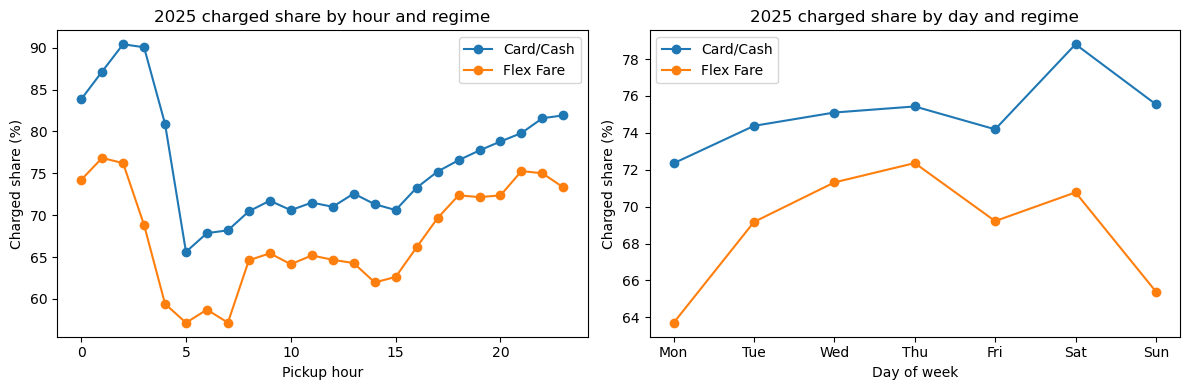

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for regime, g in regime_hour.groupby("regime"):
    axes[0].plot(g["pickup_hour"], 100 * g["charged_cbd_share"], marker="o", label=regime)
axes[0].set_title("2025 charged share by hour and regime")
axes[0].set_xlabel("Pickup hour")
axes[0].set_ylabel("Charged share (%)")
axes[0].legend()

labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for regime, g in regime_dow.groupby("regime"):
    axes[1].plot(g["day_of_week"], 100 * g["charged_cbd_share"], marker="o", label=regime)
axes[1].set_title("2025 charged share by day and regime")
axes[1].set_xlabel("Day of week")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Charged share (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

**Finding:** Flex Fare remains structurally different. Its charged share is lower than card/cash across most hours and days, and its median cost is higher. The gap is mainly a hailing-method difference: card/cash trips are **street hails**, which are structurally concentrated in the Manhattan CRZ core, so they touch the CRZ often. Flex trips are **app-dispatched** (Curb/Arro, and via Uber), which serves a more geographically dispersed set of trips — including outer-borough rides, so a smaller share touches the CRZ. Both regimes share the same time-of-day and day-of-week *shape*; Flex is simply shifted down in level. This supports keeping Flex Fare as a separate regime rather than combining it into financial-burden summaries.

## 8. Day-of-Week Seasonality of Core Outcomes

§8 shows day-of-week only, for charged share by payment regime (Flex vs card/cash). This adds the day-of-week profile of **volume and median cost** for card/cash trips, 2024 vs. 2025 — the basis for a weekday-commute vs. weekend-discretionary elasticity comparison.

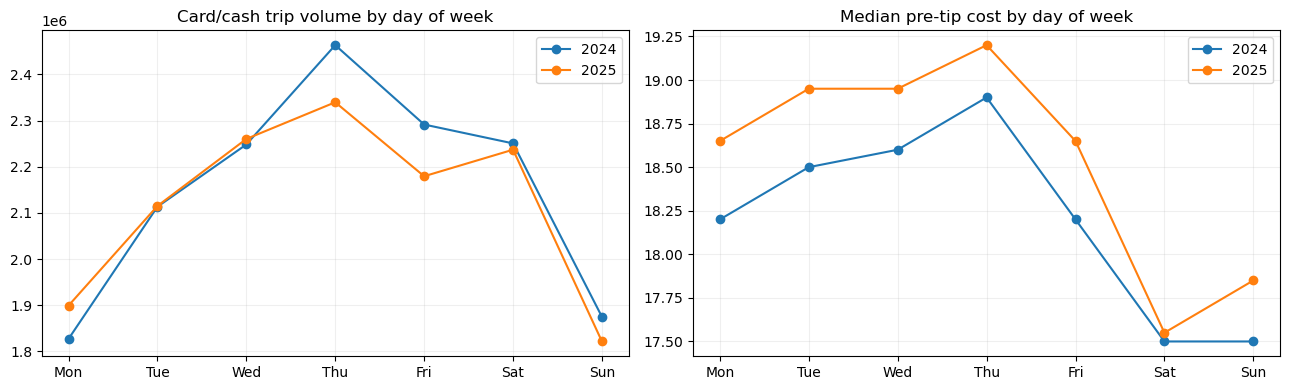

In [18]:
# Day-of-week profile of volume and cost for card/cash trips, by year (uses `main`).
dow = (
    main.groupby(["year", "day_of_week"])
    .agg(
        trip_count=("year", "size"),
        median_cost=("passenger_cost_pretip", "median"),
    )
    .reset_index()
)
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for year in [2024, 2025]:
    g = dow[dow["year"] == year].sort_values("day_of_week")
    axes[0].plot(g["day_of_week"], g["trip_count"], marker="o", label=str(year))
    axes[1].plot(g["day_of_week"], g["median_cost"], marker="o", label=str(year))
for ax, title in zip(axes, ["Card/cash trip volume by day of week",
                            "Median pre-tip cost by day of week"]):
    ax.set_title(title)
    ax.set_xticks(range(7))
    ax.set_xticklabels(labels)
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()

**Finding (day-of-week):** Both volume and median cost peak on **Thursday** and bottom out on the weekend, with Friday already tapering — card/cash yellow taxi behaves as a weekday/business-commuter service, not a weekend-leisure one (consistent with Thursday being the busiest in-office/social day post-pandemic). Across years, 2025 weekday volume (esp. Thu/Fri) sits slightly below 2024 while median cost is higher on every day, echoing the "card/cash volume flat-to-down, cost up" pattern seen earlier.

# Part II. Full-Data Validation Checks

This block validates non-time-series sample findings on the full cleaned Yellow Taxi data.

## 9. Charged Versus Not-Charged Composition

This starts the full-data validation block. The sample showed a large cost gap between charged and not-charged 2025 card/cash trips. Full data can test whether that gap reflects trip composition.

In [19]:
charged_comparison = (
    main_2025.groupby("charged_cbd_flag")
    .agg(
        rows=("year", "size"),
        median_cost=("passenger_cost_pretip", "median"),
        p25_cost=("passenger_cost_pretip", lambda s: s.quantile(0.25)),
        p75_cost=("passenger_cost_pretip", lambda s: s.quantile(0.75)),
        median_distance=("trip_distance_miles", "median"),
        median_duration_min=("trip_duration_minutes", "median"),
        airport_share=("airport_trip_flag", "mean"),
        zero_distance_share=("zero_distance_flag", "mean"),
    )
    .reset_index()
)
charged_comparison

,charged_cbd_flag,rows,median_cost,p25_cost,p75_cost,median_distance,median_duration_min,airport_share,zero_distance_share
0,False,3686814,16.1000,12.3000,29.6500,1.5000,9.8167,0.1730,0.0199
1,True,11164470,19.2500,15.0500,26.2500,1.7500,13.0000,0.0508,0.0059


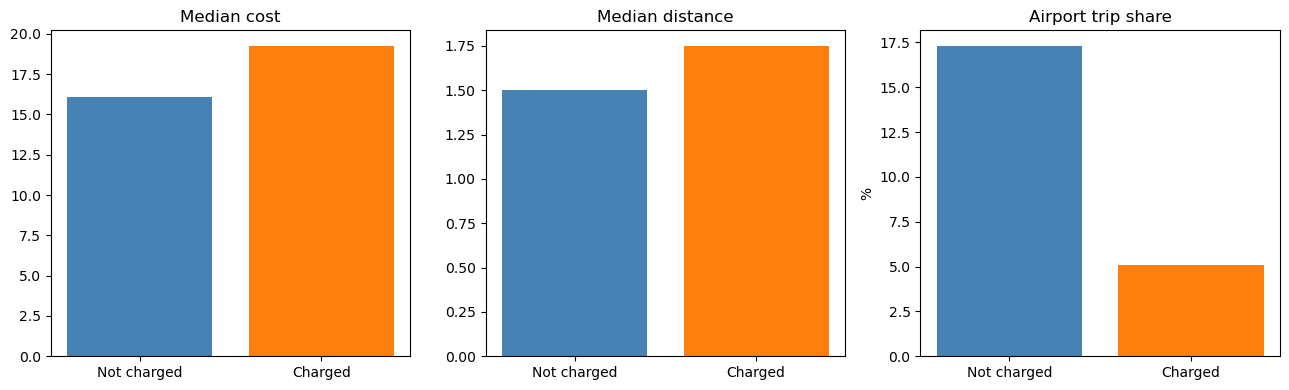

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = ["Not charged", "Charged"]
for ax, col, title in [
    (axes[0], "median_cost", "Median cost"),
    (axes[1], "median_distance", "Median distance"),
    (axes[2], "airport_share", "Airport trip share"),
]:
    vals = charged_comparison[col].to_numpy()
    if col == "airport_share":
        vals = 100 * vals
    ax.bar(labels, vals, color=["steelblue", "tab:orange"])
    ax.set_title(title)
    ax.set_ylabel("%" if col == "airport_share" else "")
plt.tight_layout()
plt.show()

**Finding:** the charged/not-charged cost gap is real: charged card/cash trips have median cost `$19.25` versus `$16.10`. It is not just the `$0.75` fee. Charged trips are longer and last longer, while not-charged trips have a much higher airport-trip share, so geography and route composition are major explanations.

## 10. Burden Distribution and Tail Behavior

This validation checks whether the sample's high-burden tail and short-trip burden pattern survive on full data.

In [21]:
distance_bins = [0, 1, 2, 5, 10, 20, np.inf]
distance_labels = ["(0,1]", "(1,2]", "(2,5]", "(5,10]", "(10,20]", "20+"]
main_2025["distance_bucket"] = pd.cut(
    main_2025["trip_distance_miles"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True,
)

distance_exposure = (
    main_2025.groupby("distance_bucket", observed=False)
    .agg(
        rows=("year", "size"),
        charged_cbd_share=("charged_cbd_flag", "mean"),
        median_cost=("passenger_cost_pretip", "median"),
        median_relative_burden_charged=("relative_cbd_burden", lambda s: s[main_2025.loc[s.index, "charged_cbd_flag"]].median()),
    )
    .reset_index()
)
distance_exposure

,distance_bucket,rows,charged_cbd_share,median_cost,median_relative_burden_charged
0,"(0,1]",3793074,0.6799,12.6500,0.0575
1,"(1,2]",4877565,0.7795,16.8000,0.0437
2,"(2,5]",3757534,0.8594,23.8500,0.0311
3,"(5,10]",1231928,0.6909,41.0500,0.0186
4,"(10,20]",1052608,0.6182,76.5000,0.0092
5,20+,138575,0.3764,86.6900,0.0090


In [22]:
burden_quantiles = charged_main_2025["relative_cbd_burden"].dropna().quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("relative_cbd_burden")
burden_quantiles["burden_pct"] = 100 * burden_quantiles["relative_cbd_burden"]
burden_quantiles

,relative_cbd_burden,burden_pct
0.2500,0.0286,2.8571
0.5000,0.0390,3.8961
0.7500,0.0498,4.9834
0.9000,0.0593,5.9289
0.9500,0.0649,6.4935
0.9900,0.0761,7.6142


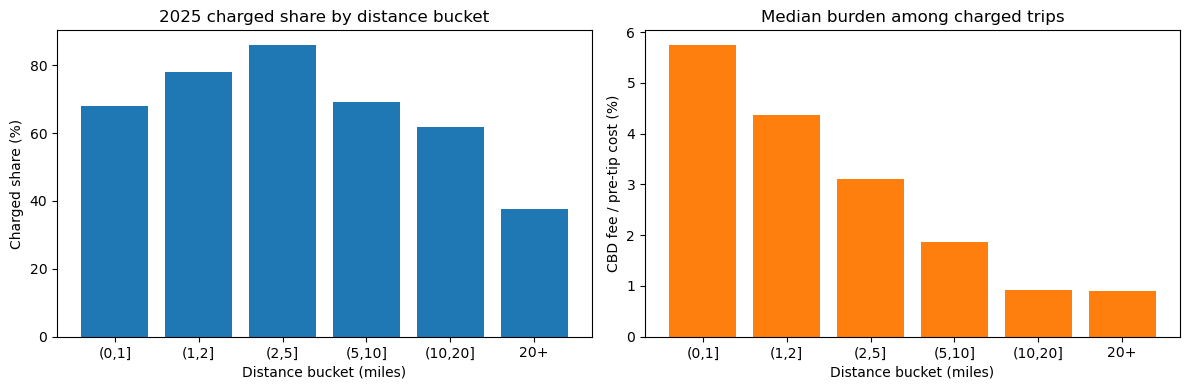

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(distance_exposure["distance_bucket"].astype(str), 100 * distance_exposure["charged_cbd_share"])
axes[0].set_title("2025 charged share by distance bucket")
axes[0].set_xlabel("Distance bucket (miles)")
axes[0].set_ylabel("Charged share (%)")

axes[1].bar(distance_exposure["distance_bucket"].astype(str), 100 * distance_exposure["median_relative_burden_charged"], color="tab:orange")
axes[1].set_title("Median burden among charged trips")
axes[1].set_xlabel("Distance bucket (miles)")
axes[1].set_ylabel("CBD fee / pre-tip cost (%)")
plt.tight_layout()
plt.show()

**Finding:** burden is clearly regressive with respect to trip length. Median burden falls from about `5.7%` for trips under one mile to below `1%` for trips over ten miles. The full-data p99 burden is about `7.6%`, far below the sample p99 of `25%`, so the sample overstated the burden tail. Charged share also varies with distance: it peaks at mid-range trips (~86% for 2–5 mi, the core Manhattan/cross-core trips) and is lowest for the longest trips (~38% for 20+ mi), which tend to run to far outer areas/airports that don't pass through the CRZ.

## 11. Full-Data Geography

The sample zone rankings were directional only. Full data gives stable pickup, dropoff, and OD rankings for 2025 charged card/cash trips.

In [24]:
zone_lookup = pd.read_csv(ZONE_LOOKUP_PATH)[["LocationID", "Borough", "Zone"]]

charged_2025 = charged_main_2025.copy()

top_pickups = (
    charged_2025.groupby("PULocationID")
    .agg(
        charged_trips=("year", "size"),
        median_relative_burden=("relative_cbd_burden", "median"),
        median_cost=("passenger_cost_pretip", "median"),
    )
    .sort_values("charged_trips", ascending=False)
    .head(15)
    .reset_index()
    .merge(zone_lookup, left_on="PULocationID", right_on="LocationID", how="left")
    .drop(columns="LocationID")
)

top_pickups[["Borough", "Zone", "PULocationID", "charged_trips", "median_relative_burden", "median_cost"]]

,Borough,Zone,PULocationID,charged_trips,median_relative_burden,median_cost
0,Manhattan,Midtown Center,161,743423,0.0402,18.6500
1,Manhattan,Penn Station/Madison Sq West,186,543889,0.0396,18.9500
2,Manhattan,Midtown East,162,539313,0.0411,18.2500
3,Manhattan,Times Sq/Theatre District,230,524939,0.0396,18.9500
4,Manhattan,Midtown North,163,442187,0.0411,18.2500
5,Manhattan,Murray Hill,170,425246,0.0418,17.9500
6,Manhattan,Union Sq,234,423271,0.0427,17.5500
7,Manhattan,Upper East Side South,237,411260,0.0418,17.9500
8,Manhattan,East Chelsea,68,402988,0.0382,19.6500
9,Manhattan,Clinton East,48,371572,0.0437,17.1500


In [25]:
top_dropoffs = (
    charged_2025.groupby("DOLocationID")
    .agg(
        charged_trips=("year", "size"),
        median_relative_burden=("relative_cbd_burden", "median"),
        median_cost=("passenger_cost_pretip", "median"),
    )
    .sort_values("charged_trips", ascending=False)
    .head(15)
    .reset_index()
    .merge(zone_lookup, left_on="DOLocationID", right_on="LocationID", how="left")
    .drop(columns="LocationID")
)

top_dropoffs[["Borough", "Zone", "DOLocationID", "charged_trips", "median_relative_burden", "median_cost"]]

,Borough,Zone,DOLocationID,charged_trips,median_relative_burden,median_cost
0,Manhattan,Midtown Center,161,576585,0.0427,17.5500
1,Manhattan,Times Sq/Theatre District,230,465396,0.0388,19.3500
2,Manhattan,Murray Hill,170,433585,0.0435,17.2500
3,Manhattan,Midtown East,162,420845,0.0435,17.2500
4,Manhattan,East Chelsea,68,382737,0.0427,17.5500
5,Manhattan,Midtown North,163,380933,0.0427,17.5500
6,Manhattan,Union Sq,234,373578,0.0445,16.8500
7,Manhattan,Upper East Side South,237,367114,0.0427,17.5500
8,Manhattan,Clinton East,48,347164,0.0411,18.2500
9,Manhattan,Penn Station/Madison Sq West,186,321548,0.0427,17.5500


In [26]:
top_od = (
    charged_2025.groupby(["PULocationID", "DOLocationID"])
    .agg(
        charged_trips=("year", "size"),
        median_relative_burden=("relative_cbd_burden", "median"),
        median_cost=("passenger_cost_pretip", "median"),
    )
    .sort_values("charged_trips", ascending=False)
    .head(20)
    .reset_index()
    .merge(zone_lookup, left_on="PULocationID", right_on="LocationID", how="left")
    .rename(columns={"Borough": "PU_Borough", "Zone": "PU_Zone"})
    .drop(columns="LocationID")
    .merge(zone_lookup, left_on="DOLocationID", right_on="LocationID", how="left")
    .rename(columns={"Borough": "DO_Borough", "Zone": "DO_Zone"})
    .drop(columns="LocationID")
)

top_od[["PU_Borough", "PU_Zone", "PULocationID", "DO_Borough", "DO_Zone", "DOLocationID", "charged_trips", "median_relative_burden", "median_cost"]]

,PU_Borough,PU_Zone,PULocationID,DO_Borough,DO_Zone,DOLocationID,charged_trips,median_relative_burden,median_cost
0,Manhattan,Midtown Center,161,Manhattan,Upper East Side South,237,56254,0.0485,15.4500
1,Manhattan,Upper East Side South,237,Manhattan,Midtown Center,161,49675,0.0495,15.1500
2,Manhattan,Midtown Center,161,Manhattan,Upper East Side North,236,46094,0.0382,19.6500
3,Manhattan,Upper East Side South,237,Manhattan,Midtown East,162,39212,0.0534,14.0500
4,Manhattan,Upper East Side North,236,Manhattan,Midtown Center,161,36608,0.0396,18.9500
5,Manhattan,Penn Station/Madison Sq West,186,Manhattan,Times Sq/Theatre District,230,35332,0.0435,17.2500
6,Manhattan,Midtown East,162,Manhattan,Upper East Side South,237,34076,0.0508,14.7500
7,Queens,JFK Airport,132,Manhattan,Times Sq/Theatre District,230,33336,0.0090,83.4400
8,Manhattan,Midtown Center,161,Manhattan,Union Sq,234,31362,0.0435,17.2500
9,Manhattan,Midtown Center,161,Manhattan,Midtown Center,161,31263,0.0593,12.6500


**Finding:** the top charged pickup and dropoff zones are mostly core Manhattan zones. Airport zones also appear because charged airport-to-CBD trips are high-volume but have low relative burden due to high fares.

## 12. Summary

**Confirmed sample findings**
- 2025 card/cash median cost is consistently higher than 2024 in same-month comparisons.
- Pickup-hour charged share is genuinely uneven, with lowest exposure around early morning and highest exposure late night.
- Flex Fare should remain separate from card/cash financial analysis.
- Zone and OD rankings should be based on full data; leading charged-trip corridors are concentrated in Manhattan, with airport corridors visible but lower-burden.

**Revised sample findings**
- The sample's April 2025 distance anomaly is not a strong full-data signal.
- The sample overstated the high-burden tail; full-data p99 relative burden is about `7.6%`, not `25%`.

**New full-data interpretation**
- The May cost/duration peak appears broader than Memorial Day alone. Median duration is highest in early May in both years, while late May has higher airport share.
- Charged trips are more expensive partly because they are longer and less airport-heavy than not-charged trips.
